In [18]:
import os
import nltk
import spacy
import string
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset
from nltk.corpus import stopwords
from mlflow.models.signature import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
RAW_MODEL_NAME = "TF_IDF Model [RAW]"
PROCESSED_MODEL_NAME = "TF_IDF Model [PROCESSED]"

In [20]:
mlflow.set_tracking_uri("http://localhost:5012")

mlflow.autolog(log_models=False)

if not mlflow.get_experiment_by_name(name=RAW_MODEL_NAME):
    print(f"Creating model: {RAW_MODEL_NAME}")
    mlflow.create_experiment(name=RAW_MODEL_NAME, artifact_location="mlflow-artifacts:/tfidf_model-raw")


if not mlflow.get_experiment_by_name(name=PROCESSED_MODEL_NAME):
    print(f"Creating model: {PROCESSED_MODEL_NAME}")
    mlflow.create_experiment(name=PROCESSED_MODEL_NAME, artifact_location="mlflow-artifacts:/tfidf_model-processed")


raw_tfidf_experiment = mlflow.get_experiment_by_name(name=RAW_MODEL_NAME)
processed_tfidf_experiment = mlflow.get_experiment_by_name(name=PROCESSED_MODEL_NAME)

2026/05/16 03:40:52 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [21]:
IMDB_DATA_PATH_TRAIN = "data/raw/imdb_train.csv"
IMDB_DATA_PATH_TEST = "data/raw/imdb_test.csv"

In [22]:
dataset_hf = load_dataset("imdb", cache_dir="data/cache")

# Pre Processing

In [23]:
def clean_text(text: str) -> str:
    """
    Do some text cleaning and tokenizing
    """

    text = str(text).lower()
    text = text.replace("<br />", " ") # Remove html tags
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    doc = nlp(text)
    cleaned_tokens = [
        token.lemma_ for token in doc
        if token.text not in stop_words and token.is_alpha
    ]

    return " ".join(cleaned_tokens)

In [24]:
# Download stopwords
if not os.path.exists(IMDB_DATA_PATH_TRAIN) or not os.path.exists(IMDB_DATA_PATH_TEST) :
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

    nlp = spacy.load("en_core_web_sm")

    df_test = pd.DataFrame(dataset_hf['test'])
    df_train = pd.DataFrame(dataset_hf['train'])

    tqdm.pandas(desc='Cleaning Text...') 
    df_test['text_processed'] = df_test['text'].progress_apply(clean_text)
    df_train['text_processed'] = df_train['text'].progress_apply(clean_text)

    df_test.to_csv(IMDB_DATA_PATH_TEST, columns=['label', 'text_processed'], index=False)
    df_train.to_csv(IMDB_DATA_PATH_TRAIN, columns=['label', 'text_processed'], index=False)

# Model Training

In [25]:
vectorizer = TfidfVectorizer()

In [26]:
df_train_processed = pd.read_csv(IMDB_DATA_PATH_TRAIN)
df_test_processed = pd.read_csv(IMDB_DATA_PATH_TEST)

In [27]:
x_train_raw = vectorizer.fit_transform(dataset_hf['train']['text'])
x_test_raw = vectorizer.transform(dataset_hf['test']['text'])

In [28]:
x_train_processed = vectorizer.fit_transform(df_train_processed['text_processed'].values)
x_test_processed = vectorizer.transform(df_test_processed['text_processed'].values)

In [29]:
print(f"{'Raw Data:':<18} {x_train_raw.shape}")
print(f"{'Processed Data:':<18} {x_train_processed.shape}")

Raw Data:          (25000, 74849)
Processed Data:    (25000, 93596)


In [30]:
# ML Run on raw data
with mlflow.start_run(experiment_id=raw_tfidf_experiment.experiment_id):
    model_raw = LogisticRegression(random_state=42, max_iter=1000)
    model_raw.fit(x_train_raw, dataset_hf['train']['label'])

    # Generate Signature to save on mem usage
    sig = infer_signature(x_train_raw[:100], model_raw.predict(x_train_raw[:100]))

    # Log the sklearn model and register as version 1
    mlflow.sklearn.log_model(
        sk_model=model_raw,
        name="model_raw",
        input_example=x_train_raw[:100],
        registered_model_name="sk-learn-log-reg-tfidf-raw",
        signature=sig
    )

    raw_run = mlflow.active_run().info

2026/05/16 03:41:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Column' object has no attribute 'flatten'
2026/05/16 03:41:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'sk-learn-log-reg-tfidf-raw' already exists. Creating a new version of this model...
2026/05/16 03:41:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-log-reg-tfidf-raw, version 5
Created version '5' of model 'sk-learn-log-reg-tfidf-raw'.


🏃 View run carefree-goat-993 at: http://localhost:5012/#/experiments/4/runs/b7bcf05e59fb4081bbca4caa8bd288ee
🧪 View experiment at: http://localhost:5012/#/experiments/4


In [31]:
# ML Run on processed data
with mlflow.start_run(experiment_id=processed_tfidf_experiment.experiment_id):
    model_processed = LogisticRegression(random_state=42, max_iter=1000)
    model_processed.fit(x_train_processed, df_test_processed['label'])

    # Generate Signature to save on mem usage
    sig = infer_signature(x_train_processed[:100], model_processed.predict(x_train_processed[:100]))

    # Log the sklearn model and register as version 1
    mlflow.sklearn.log_model(
        sk_model=model_processed,
        name="model_processed",
        input_example=x_train_processed[:100],
        registered_model_name="sk-learn-log-reg-tfidf-processed",
        signature=sig
    )

    processed_run = mlflow.active_run().info

2026/05/16 03:41:53 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/05/16 03:42:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'sk-learn-log-reg-tfidf-processed' already exists. Creating a new version of this model...
2026/05/16 03:42:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sk-learn-log-reg-tfidf-processed, version 5
Created version '5' of model 'sk-learn-log-reg-tfidf-processed'.


🏃 View run beautiful-ray-557 at: http://localhost:5012/#/experiments/5/runs/e1999410b2a647949fbce8a5daf7fedf
🧪 View experiment at: http://localhost:5012/#/experiments/5


In [32]:
def eval_model(dataset, prediction, run_id):
    scores_count = np.array([[
        accuracy_score(dataset, prediction),
        recall_score(dataset, prediction),
        precision_score(dataset, prediction),
    ]])

    print(f"{'Accuracy_score':<18} {scores_count[0][0]:.4f}")
    print(f"{'Recall_score':<18} {scores_count[0][1]:.4f}")
    print(f"{'Precision_score':<18} {scores_count[0][1]:.4f}")

    mlflow.log_metrics(run_id=run_id, metrics={
        "testing_accuracy_score": scores_count[0][0],
        "testing_recall_score": scores_count[0][1],
        "testing_precision_score": scores_count[0][2],
    })

    # Generate and save Confusion Matrix
    cm = confusion_matrix(dataset, prediction, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues")
    ax.set_title("Confusion Matrix - Validation")

    plt.show()

    with mlflow.start_run(run_id=run_id):
        mlflow.log_figure(fig, "validation_confusion_matrix.png")

    plt.close()


Accuracy_score     0.8829
Recall_score       0.8814
Precision_score    0.8814


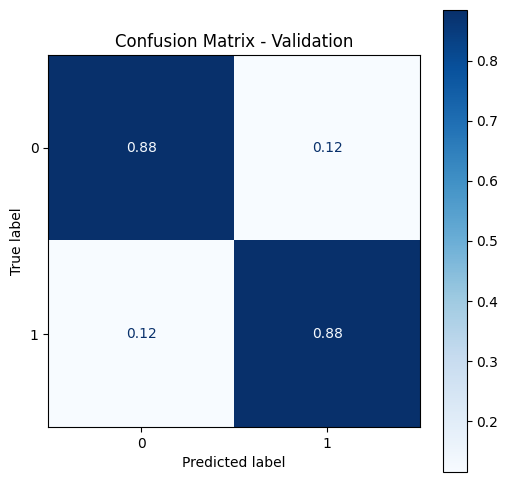

🏃 View run carefree-goat-993 at: http://localhost:5012/#/experiments/4/runs/b7bcf05e59fb4081bbca4caa8bd288ee
🧪 View experiment at: http://localhost:5012/#/experiments/4


In [33]:
# Print metrics for RAW
prediction_raw = model_raw.predict(x_test_raw)

eval_model(dataset_hf['test']['label'], prediction_raw, raw_run.run_id)

Accuracy_score     0.8795
Recall_score       0.8824
Precision_score    0.8824


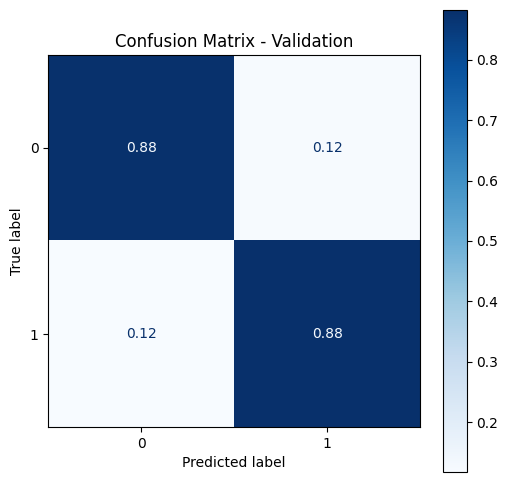

🏃 View run beautiful-ray-557 at: http://localhost:5012/#/experiments/5/runs/e1999410b2a647949fbce8a5daf7fedf
🧪 View experiment at: http://localhost:5012/#/experiments/5


In [34]:
prediction_processed = model_processed.predict(x_test_processed)

eval_model(df_test_processed['label'], prediction_processed, processed_run.run_id)